In [1]:
import base64
import io
import shutil
import os
import uuid
import matplotlib.pyplot as plt
import openai
from PIL import Image
from IPython.display import Image, HTML, Markdown, display
from unstructured.partition.pdf import partition_pdf
from dotenv import load_dotenv

from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.schema.document import Document

In [4]:
# Constants
PDF_PATH = "../kaggle_data/Data Engineering/"

OUTPUT_PATH = "./data/temp_pdfs_output/"

TEXT_DB_DIRECTORY = "med_text_db"

IMAGE_DB_DIRECTORY = "med_image_db"

VISION_MODEL = "llama-3.2-11b-vision-preview"

TEXT_MODEL = "llama-3.2-3b-preview"

EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v2"

load_dotenv()
# Get the API key from the environment
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY', 'your-key-if-not-using-env')

BASE_URL="https://api.groq.com/openai/v1"

API_KEY=os.environ.get("GROQ_API_KEY")

REMOVE_OLD_DB = False

In [5]:
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

In [6]:
store = Chroma(
    collection_name=TEXT_DB_DIRECTORY, 
    embedding_function=embeddings, 
    persist_directory=TEXT_DB_DIRECTORY
)

In [7]:
# Define the retriever
text_retriever = store.as_retriever(
   search_type="mmr", 
   search_kwargs={'k': 10, 'fetch_k': 20}
) if store else None

In [8]:
docs = text_retriever.invoke("What is CKS2?")

In [9]:
docs[0].page_content

"**Validated Sub-domain**\n<Validated Sub-domain>\nNeurology (partially applicable due to cell membrane and cytoskeleton dynamics involvement; primary focus on cellular processes)\n</Validated Sub-domain>\n\n**Clinical Classification Validation**\n\n1. **Medical concept pattern matching**: The provided sub-domain 'Neurology' is partially applicable as the element discusses cellular processes, specifically cell membrane and cytoskeleton dynamics, which are indirectly related to neurology. However, the primary focus of the element is on cellular processes, making it more relevant to a broader sub-domain like 'Cell Biology' or 'Molecular Biology'.\n2. **Clinical terminology analysis**: Key terms like 'cell membrane', 'cytoskeleton', and 'phosphorylation' are relevant to cellular biology. While some terms like 'merlin' and 'FERM-containing proteins' might be specific to neurology, their application in the context of cell membrane and cytoskeleton dynamics is more relevant to cellular biolo

In [11]:
display(Markdown(docs[0].page_content))

**Validated Sub-domain**
<Validated Sub-domain>
Neurology (partially applicable due to cell membrane and cytoskeleton dynamics involvement; primary focus on cellular processes)
</Validated Sub-domain>

**Clinical Classification Validation**

1. **Medical concept pattern matching**: The provided sub-domain 'Neurology' is partially applicable as the element discusses cellular processes, specifically cell membrane and cytoskeleton dynamics, which are indirectly related to neurology. However, the primary focus of the element is on cellular processes, making it more relevant to a broader sub-domain like 'Cell Biology' or 'Molecular Biology'.
2. **Clinical terminology analysis**: Key terms like 'cell membrane', 'cytoskeleton', and 'phosphorylation' are relevant to cellular biology. While some terms like 'merlin' and 'FERM-containing proteins' might be specific to neurology, their application in the context of cell membrane and cytoskeleton dynamics is more relevant to cellular biology.
3. **Diagnostic/therapeutic methodology alignment check**: There is no direct diagnostic or therapeutic methodology alignment with neurology, as the element focuses on molecular interactions and cellular processes.
4. **Healthcare practice contextual review**: The element's content is more relevant to basic research and cellular biology rather than clinical practice or neurology.

**Medical Key Identification**

a) **Primary condition/procedure/treatment**: None directly related to neurology; the element focuses on molecular interactions and cellular processes.

b) **Key clinical terms and medical vocabulary**: 
- Merlin
- Phosphorylation
- Cell membrane
- Cytoskeleton
- FERM-containing proteins
- CD44
- β1-integrin
- βII-spectrin
- Paxillin
- Actin
- Syntenin
- Sodium–hydrogen exchange regulatory factor
- Hepatocyte growth factor-regulated, tyrosine kinase substrate

c) **Clinical applications and patient care implications**: The element's content has limited direct clinical applications or patient care implications. However, understanding the molecular interactions and cellular processes discussed could contribute to the development of new treatments or therapies.

d) **Inter-specialty relationships and referral pathways**: The element's content is primarily relevant to cellular biology and molecular biology, with potential implications for neurology or other specialties through further research and development.

**Clinical Summary Creation**

<Summary>
Merlin, a protein involved in cell-cell contact and motility, interacts with the cell membrane through phosphorylation. This interaction is crucial for its binding to effector proteins and regulation of cellular processes. Merlin's localization to the cell membrane is associated with regions that regulate cell-cell contact and motility. Several merlin-interacting proteins have been identified, including cell-surface proteins, cytoskeleton dynamics molecules, and proteins involved in ion transport and endocytosis.

**Clinical Relevance**: Understanding the molecular interactions and cellular processes discussed in this element could contribute to the development of new treatments or therapies, particularly in the context of cellular biology and molecular biology. However, the primary focus of this element is on basic research and cellular processes, making it less directly relevant to neurology.

**Vector Alignment**: The element's content is structured around the pathophysiological relationships between merlin, phosphorylation, cell membrane, and cytoskeleton dynamics. This nested pathophysiological relationship is essential for vector alignment and clinical decision-making support.

**Evidence-based Prioritization**: The element's content is primarily based on research and molecular interactions, with limited direct clinical applications or patient care implications. However, the discussion of merlin-interacting proteins and their roles in cellular processes is crucial for understanding the underlying molecular mechanisms.

**Medical Specialty-specific Framing**: The element's content is primarily relevant to cellular biology and molecular biology, with potential implications for neurology or other specialties through further research and development.

In [8]:
docs[9].metadata

{'category': 'Data Engineering',
 'doc_id': 'a5afe368-fbc4-4c37-b301-9e7449575639',
 'filename': 'GDE.pdf',
 'page_number': 4,
 'raw_text': 'Data Model\n\nData tables are organized into units called datasets, which are sets of tables and views. A table must belong to da- taset and a datatset must belong to a porject. Tables contain records with rows and columns (ﬁelds). You can load data into BigQuery via two options: batch loading (free) and streaming (costly).'}

In [9]:
image_store = Chroma(
    collection_name=IMAGE_DB_DIRECTORY, 
    embedding_function=embeddings, 
    persist_directory=IMAGE_DB_DIRECTORY
)

In [13]:
image_retriever = image_store.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={'score_threshold': 0.2}
) if image_store else None

# Setting needed to ignore the warning as the current langchain framework will have a warning when the score is below 0.
# This will be handled later by checking if the retrieved images count is 0.
import warnings

# Suppress warnings that match the specific message
warnings.filterwarnings("ignore", message="Relevance scores must be between 0 and 1")

In [26]:
image_retriever = image_store.as_retriever(
    search_kwargs={'k': 5}
) if image_store else None

In [27]:
docs = image_retriever.invoke("Example of relational database?")

In [34]:
display(Markdown(docs[3].page_content))

**A Table of Follows Relationships**

The image presents a table illustrating a "follows" column family. The table consists of two rows and five columns, with the following column headers: "Row Key," "gwashington," "jadams," "tjefferson," and "wmckinley." Each cell in the table contains a value of "1," indicating a follows relationship between the row key and the corresponding column name.

**Data Science Perspective**

From a data science perspective, this table represents a simple many-to-many relationship between entities in the "follows" column family. The presence of a "1" in each cell suggests that there is a follows relationship between the row key and the corresponding column name. This type of data structure is commonly used in social network analysis and graph databases to represent relationships between entities.

**Insights and Observations**

One possible interpretation of this table is that it represents a social network where individuals are connected to each other based on their follows relationships. For example, the row key "gwashington" is connected to "tjefferson," indicating that gwashington follows tjefferson. Similarly, "tjefferson" is connected to "jadams," indicating that tjefferson follows jadams.

**Conclusion**

In conclusion, the image represents a table of follows relationships between entities in the "follows" column family. From a data science perspective, this table can be used to analyze and understand the relationships between entities in a social network.

In [29]:
def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

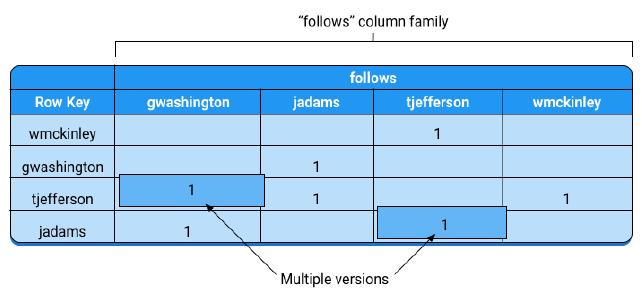

In [33]:
display_base64_image(docs[3].metadata.get("base64_image"))

In [35]:
for doc in docs:
    print(doc.metadata.get("filename"))

GDE.pdf
Data Engineering CookBook.pdf
GDE.pdf
GDE.pdf
Data Engineering CookBook.pdf


In [5]:
all_data = store._collection.get()

In [11]:
all_data['metadatas'][31]

{'category': 'Big Data',
 'doc_id': '3dfa629c-997b-433a-a578-d4724da9f5a0',
 'filename': 'Data Warehouse Concepts.pdf',
 'page_number': 11,
 'raw_text': 'Page 11 of 11'}

In [7]:
len(all_data['metadatas'])

75

In [19]:
category = "Data Warehouse"

documents = []
for i, doc_id in enumerate(all_data["ids"]):
    if i >=32:
        break

    summary_text = all_data["documents"][i]
    metadata = all_data["metadatas"][i]
    
    doc = Document(
        page_content=summary_text,
        metadata={
            "doc_id": doc_id,
            "raw_text": metadata.get("raw_text"),
            "page_number": metadata.get("page_number"),
            "filename": metadata.get("filename"),
            "category": category
        },
        id=doc_id,
    )
    documents.append(doc)



In [20]:
len(documents)

32

In [23]:
documents[31].metadata

{'doc_id': '3dfa629c-997b-433a-a578-d4724da9f5a0',
 'raw_text': 'Page 11 of 11',
 'page_number': 11,
 'filename': 'Data Warehouse Concepts.pdf',
 'category': 'Data Warehouse'}

In [11]:
dw_data = store.similarity_search(
    "Data Warehouse Concepts.pdf",
    k=50,
    filter={"category": "Data Warehouse Concepts.pdf"},
)

In [ ]:
dw_data[0]

In [13]:
len(dw_data)

32

In [22]:
# Check if all category of dw_data is "Data Warehouse Concepts.pdf"
all([doc.metadata.get("category") == "Data Warehouse Concepts.pdf" for doc in dw_data])

True

In [ ]:
for doc in dw_data:
    uuid = doc.metadata.get("doc_id")

In [24]:
len(dw_data)

32

In [24]:
len(documents)

32

In [ ]:
documents[267].metadata

In [ ]:
documents[0].id

In [ ]:
store.update_document(document_id=documents[0].id, document=documents[0])

In [25]:
for doc in documents:
    store.update_document(document_id=doc.id, document=doc)

In [32]:
update_all_data = store._collection.get()

In [ ]:
update_all_data['metadatas'][31]

{'category': 'Data Warehouse',
 'doc_id': '3dfa629c-997b-433a-a578-d4724da9f5a0',
 'filename': 'Data Warehouse Concepts.pdf',
 'page_number': 11,
 'raw_text': 'Page 11 of 11'}

In [33]:
len(update_all_data['metadatas'])

352